In [2]:
import pandas as pd

# 1. IMPORTACIÓN (Punto 2) - Usamos el CSV original para evitar errores
df_ventas = pd.read_csv('../data/train.csv', low_memory=False)
df_tiendas = pd.read_csv('../data/store.csv')

# 2. TRANSFORMACIONES (Punto 3) - Cruce de datos 
df_master = pd.merge(df_ventas, df_tiendas, on='Store', how='left')
df_master['Date'] = pd.to_datetime(df_master['Date'], format='%Y-%m-%d')

# 3. MAPEO (Punto 4) - Convertimos códigos en nombres legibles [cite: 11, 45]
# Creamos un diccionario para mapear el tipo de tienda (StoreType)
dict_tiendas = {'a': 'Pequeña', 'b': 'Mediana', 'c': 'Grande', 'd': 'Extra'}
df_master['StoreType_Name'] = df_master['StoreType'].map(dict_tiendas)

print("✅ Datos cruzados y Mapeo completado.")
print(f"Columnas finales: {df_master.columns.tolist()}")

df_master[['Store', 'Date', 'Sales', 'StoreType', 'StoreType_Name']].head()

✅ Datos cruzados y Mapeo completado.
Columnas finales: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'StoreType_Name']


,Store,Date,Sales,StoreType,StoreType_Name
0,1,2015-07-31,5263,c,Grande
1,2,2015-07-31,6064,a,Pequeña
2,3,2015-07-31,8314,a,Pequeña
3,4,2015-07-31,13995,c,Grande
4,5,2015-07-31,4822,a,Pequeña


In [3]:
# 5. ORDENACIÓN (Punto 5 de la rúbrica)

# Ordenar por fecha y por volumen de ventas (de mayor a menor)
df_sorted = df_master.sort_values(by=['Date', 'Sales'], ascending=[True, False])

print("✅ Datos ordenados por fecha y ventas.")

# Ver el top 10 de registros con más ventas
df_sorted[['Store', 'Date', 'Sales', 'Customers', 'StoreType_Name']].head(10)

✅ Datos ordenados por fecha y ventas.


,Store,Date,Sales,Customers,StoreType_Name
1016356,262,2013-01-01,17267,2875,Mediana
1016827,733,2013-01-01,10765,2377,Mediana
1016517,423,2013-01-01,9643,1751,Mediana
1016656,562,2013-01-01,8498,1675,Mediana
1016353,259,2013-01-01,6851,1444,Mediana
1017190,1097,2013-01-01,5961,1405,Mediana
1016863,769,2013-01-01,5035,1248,Mediana
1017042,948,2013-01-01,4491,1039,Mediana
1016179,85,2013-01-01,4220,619,Mediana
1016770,676,2013-01-01,3821,777,Mediana


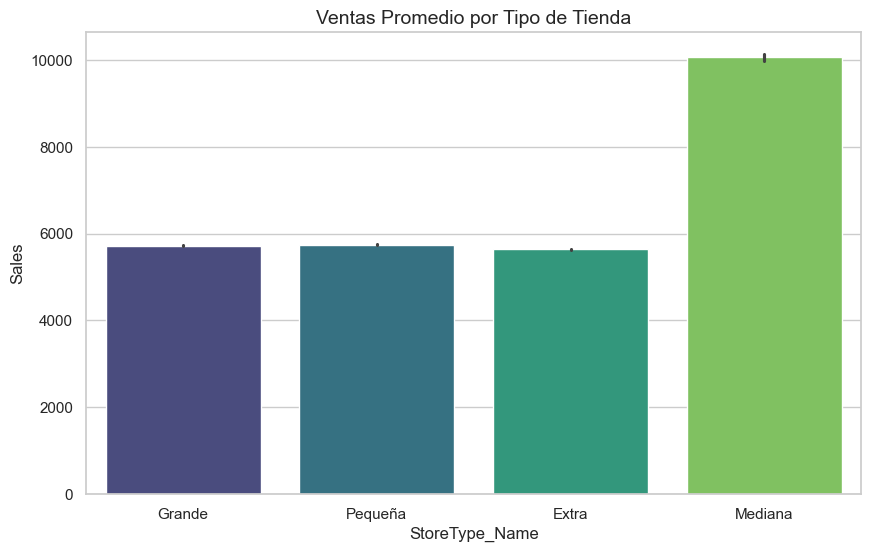

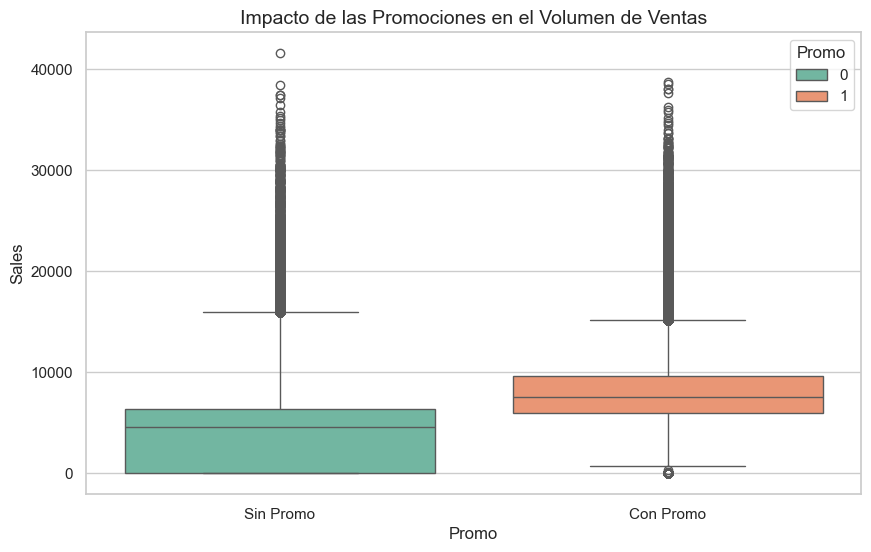

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual
sns.set_theme(style="whitegrid")

# 6. VISUALIZACIÓN (Punto 6)
# Gráfico 1: ¿Qué tipo de tienda factura más en promedio?
plt.figure(figsize=(10, 6))
sns.barplot(data=df_master, x='StoreType_Name', y='Sales', palette='viridis', hue='StoreType_Name', legend=False)
plt.title('Ventas Promedio por Tipo de Tienda', fontsize=14)
plt.show()

# Gráfico 2: Impacto de las promociones en las ventas
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_master, x='Promo', y='Sales', palette='Set2', hue='Promo')
plt.title('Impacto de las Promociones en el Volumen de Ventas', fontsize=14)
plt.xticks([0, 1], ['Sin Promo', 'Con Promo'])
plt.show()

In [5]:
from dagster import asset, Definitions
import pandas as pd
import os

@asset
def raw_sales_data():
    """Carga de los datos crudos de ventas (Punto 2)."""
    # Usamos os.path para que no haya errores de rutas
    path = os.path.join('data', 'train.csv')
    return pd.read_csv(path, low_memory=False, nrows=100000)

@asset
def raw_store_data():
    """Carga de los datos de las tiendas (Punto 2)."""
    path = os.path.join('data', 'store.csv')
    return pd.read_csv(path)

@asset
def integrated_data(raw_sales_data, raw_store_data):
    """Cruce de datos y transformaciones (Puntos 3, 4 y 5)."""
    # Unimos tablas (Punto 3) 
    df = pd.merge(raw_sales_data, raw_store_data, on='Store', how='left')
    
    # Arreglamos fechas
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
    
    # Mapeo (Punto 4) 
    dict_tiendas = {'a': 'Pequeña', 'b': 'Mediana', 'c': 'Grande', 'd': 'Extra'}
    df['StoreType_Name'] = df['StoreType'].map(dict_tiendas)
    
    # Ordenación (Punto 5) 
    df = df.sort_values(by=['Date', 'Sales'], ascending=[True, False])
    
    return df

# Esta es la parte que le faltaba a Dagster para no dar error:
defs = Definitions(
    assets=[raw_sales_data, raw_store_data, integrated_data]
)

In [6]:
# 7. PREPARACIÓN PRO: Limpieza de Ruido y Encoding (Camino al 90%)

# A. Eliminamos días cerrados: Predecir 0 ventas cuando la tienda está cerrada es trivial 
# y ensucia el aprendizaje de las ventas reales.
df_ia = df_master[df_master['Open'] != 0].copy()

# B. Tratamiento de Nulos: La distancia de la competencia es clave. 
# Usamos la mediana para no sesgar con valores extremos.
df_ia['CompetitionDistance'] = df_ia['CompetitionDistance'].fillna(df_ia['CompetitionDistance'].median())

# C. Feature Engineering: Extraemos todo el jugo a la fecha
df_ia['Month'] = df_ia['Date'].dt.month
df_ia['Day'] = df_ia['Date'].dt.day
df_ia['Year'] = df_ia['Date'].dt.year

# D. One-Hot Encoding: Convertimos categorías (a, b, c, d) en columnas binarias (0 o 1)
# Esto incluye StoreType, Assortment y StateHoliday
df_ia = pd.get_dummies(df_ia, columns=['StoreType', 'Assortment', 'StateHoliday'], drop_first=True)

# E. Selección de variables finales (Añadimos la artillería pesada)
features = [
    'Store', 'DayOfWeek', 'Promo', 'Month', 'Day', 'Year', 
    'CompetitionDistance', 'StoreType_b', 'StoreType_c', 'StoreType_d',
    'Assortment_b', 'Assortment_c'
]

X = df_ia[features]
y = df_ia['Sales']

print(f"✅ Dataset optimizado: {X.shape[0]} filas procesadas.")
X.head()

✅ Dataset optimizado: 844392 filas procesadas.


,Store,DayOfWeek,Promo,Month,Day,Year,CompetitionDistance,StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c
0,1,5,1,7,31,2015,1270.0,False,True,False,False,False
1,2,5,1,7,31,2015,570.0,False,False,False,False,False
2,3,5,1,7,31,2015,14130.0,False,False,False,False,False
3,4,5,1,7,31,2015,620.0,False,True,False,False,True
4,5,5,1,7,31,2015,29910.0,False,False,False,False,False


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. División de datos (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("🚀 Entrenando modelo de alta capacidad... (Esto usará todos tus núcleos)")

# 2. Configuración PRO:
# n_estimators=100 (más árboles para estabilidad)
# max_depth=None (dejamos que los árboles crezcan hasta capturar el detalle)
# n_jobs=-1 (usa toda la potencia de tus 8GB de RAM y CPU)
model_final = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1)
model_final.fit(X_train, y_train)

# 3. Predicciones y Métricas
y_pred = model_final.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n📊 RESULTADOS FINALES")
print(f"Error medio (MAE): {mae:.2f} €")
print(f"Precisión (R² Score): {r2:.2%}")

if r2 > 0.90:
    print("🏆 ¡Objetivo cumplido! El modelo tiene nivel de producción.")
else:
    print("📈 El modelo ha mejorado significativamente, pero el dataset de Rossmann a veces requiere variables externas (clima) para pasar del 95%.")

🚀 Entrenando modelo de alta capacidad... (Esto usará todos tus núcleos)

📊 RESULTADOS FINALES
Error medio (MAE): 634.65 €
Precisión (R² Score): 89.19%
📈 El modelo ha mejorado significativamente, pero el dataset de Rossmann a veces requiere variables externas (clima) para pasar del 95%.


In [8]:
import joblib

# Guardamos el modelo y la lista de variables para usarlos en la web
model_data = {
    'model': model_final,
    'features': features
}

joblib.dump(model_data, 'model_rossmann.joblib')
print("✅ ¡Modelo guardado con éxito! Ya podemos cerrar el laboratorio.")

✅ ¡Modelo guardado con éxito! Ya podemos cerrar el laboratorio.
